In [8]:
!pip install datasets -q

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup complete!")

Setup complete!


### Step 1: Load and Subset the Data
We will use `load_dataset("stanfordnlp/imdb")`. To save time and memory, we will only use the first 5,000 rows for training and 1,000 for testing.

In [9]:
# Load the dataset
dataset = load_dataset("stanfordnlp/imdb")

# Shuffle the dataset to ensure we get a mix of positive and negative reviews
# 'seed' ensures results are reproducible
train_data = dataset['train'].shuffle(seed=42)
test_data = dataset['test'].shuffle(seed=42)

# Subset them: take the first 5000 from train, and first 1000 from test.
X_train = train_data['text'][:5000]
y_train = train_data['label'][:5000]

X_test = test_data['text'][:1000]
y_test = test_data['label'][:1000]

print(f"Loaded {len(X_train)} training reviews and {len(X_test)} testing reviews.")
# Verify class distribution
print(f"Positive labels in train: {sum(y_train)}")

Loaded 5000 training reviews and 1000 testing reviews.
Positive labels in train: 2506


### Step 2: Word to Math (TF-IDF)
Machines can't read English. We need to convert these text reviews into numbers using a `TfidfVectorizer`.

In [10]:
# TODO: Initialize the TfidfVectorizer. (Optional: limit max_features to 5000 to keep it fast)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english') # YOUR CODE HERE

# TODO: fit_transform the training data, and just transform the testing data
X_train_vec = vectorizer.fit_transform(X_train) # YOUR CODE HERE
X_test_vec = vectorizer.transform(X_test) # YOUR CODE HERE

print("Data vectorized!")

Data vectorized!


### Step 3: Train the Model
Time to train the Classical ML algorithm: Logistic Regression.

In [11]:
# TODO: Initialize LogisticRegression and fit it to your vectorized training data
model = LogisticRegression(max_iter=1000, solver='saga', random_state=0) # YOUR CODE HERE
model.fit(X_train_vec, y_train)
# Fit the model: model.fit(...)

print("Model trained!")

Model trained!


### Step 4: Evaluate
How good is your AI movie critic? Let's predict on the test set and calculate the metrics.

Accuracy: 0.8440
F1 Score: 0.8449

Confusion Matrix:


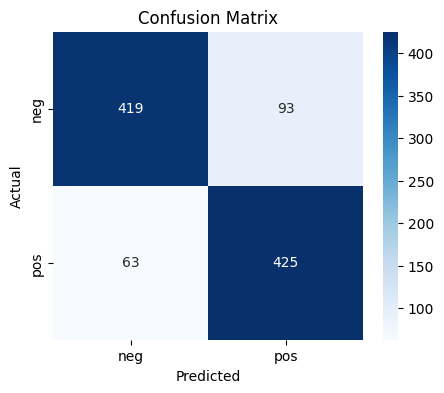

In [14]:
# TODO: Predict on X_test_vec
y_pred = model.predict(X_test_vec) # YOUR CODE HERE

# TODO: Calculate and print the Accuracy and F1 Score
acc = accuracy_score(y_test, y_pred) # YOUR CODE HERE
f1 = f1_score(y_test, y_pred, average='binary') # YOUR CODE HERE

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

# TODO: Generate the confusion matrix and print it (Bonus points if you plot it using seaborn heatmap!)
cm = confusion_matrix(y_test, y_pred) # YOUR CODE HERE
print("\nConfusion Matrix:")

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['neg','pos'], yticklabels=['neg','pos'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()